In [80]:
from google.colab import drive
drive.mount('/content/drive')


Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [117]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.preprocessing import StandardScaler
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score
from sklearn.model_selection import learning_curve
from sklearn.linear_model import LogisticRegression
from sklearn.svm import SVC
from sklearn.ensemble import GradientBoostingClassifier
from sklearn.tree import DecisionTreeClassifier

import joblib

In [118]:
import pandas as pd

columns = [
"Subject_ID",
"Jitter_local","Jitter_abs","Jitter_rap","Jitter_ppq5","Jitter_ddp",
"Shimmer_local","Shimmer_dB","Shimmer_apq3","Shimmer_apq5","Shimmer_apq11","Shimmer_dda",
"AC","NTH","HTN",
"Median_pitch","Mean_pitch","Std_pitch","Min_pitch","Max_pitch",
"Num_pulses","Num_periods","Mean_period","Std_period",
"Frac_unvoiced","Num_voice_breaks","Degree_voice_breaks",
"UPDRS",
"Class"
]

train_df = pd.read_csv(
"/content/drive/MyDrive/Parkinson's Dataset for Mlops Project/parkinson+speech+dataset+with+multiple+types+of+sound+recordings/train_data.txt",
sep=",",
header=None,
names=columns
)

train_df.shape

(1040, 29)

In [119]:
train_df.head()

,Subject_ID,Jitter_local,Jitter_abs,Jitter_rap,Jitter_ppq5,Jitter_ddp,Shimmer_local,Shimmer_dB,Shimmer_apq3,Shimmer_apq5,...,Max_pitch,Num_pulses,Num_periods,Mean_period,Std_period,Frac_unvoiced,Num_voice_breaks,Degree_voice_breaks,UPDRS,Class
0,1,1.488,0.000090,0.900,0.794,2.699,8.334,0.779,4.517,4.609,...,187.576,160,159,0.006065,0.000416,0.000,0,0.000,23,1
1,1,0.728,0.000038,0.353,0.376,1.059,5.864,0.642,2.058,3.180,...,234.505,170,169,0.005181,0.000403,2.247,0,0.000,23,1
2,1,1.220,0.000074,0.732,0.670,2.196,8.719,0.875,4.347,5.166,...,211.442,1431,1427,0.006071,0.000474,10.656,1,0.178,23,1
3,1,2.502,0.000123,1.156,1.634,3.469,13.513,1.273,5.263,8.771,...,220.230,94,92,0.004910,0.000320,0.000,0,0.000,23,1
4,1,3.509,0.000167,1.715,1.539,5.145,9.112,1.040,3.102,4.927,...,225.162,117,114,0.004757,0.000380,18.182,1,13.318,23,1


In [120]:
train_df.tail()

,Subject_ID,Jitter_local,Jitter_abs,Jitter_rap,Jitter_ppq5,Jitter_ddp,Shimmer_local,Shimmer_dB,Shimmer_apq3,Shimmer_apq5,...,Max_pitch,Num_pulses,Num_periods,Mean_period,Std_period,Frac_unvoiced,Num_voice_breaks,Degree_voice_breaks,UPDRS,Class
1035,40,5.127,0.000398,2.721,2.510,8.162,9.846,0.965,4.593,6.806,...,158.591,63,60,0.007766,0.001066,24.194,2,15.113,1,0
1036,40,1.757,0.000133,0.808,0.690,2.425,7.571,0.740,2.720,3.927,...,143.797,47,44,0.007561,0.000430,46.053,1,25.792,1,0
1037,40,2.912,0.000226,1.141,1.266,3.423,15.489,1.456,6.433,10.138,...,149.641,79,77,0.007767,0.000881,20.000,1,4.574,1,0
1038,40,3.788,0.000275,1.786,1.484,5.359,15.702,1.367,6.374,11.094,...,451.366,75,70,0.007257,0.001714,16.667,3,19.575,1,0
1039,40,1.809,0.000149,0.680,0.843,2.040,7.881,0.782,2.690,4.543,...,137.546,62,60,0.008211,0.000566,18.182,1,3.387,1,0


In [121]:
train_df.isnull().sum()

,0
Subject_ID,0
Jitter_local,0
Jitter_abs,0
Jitter_rap,0
Jitter_ppq5,0
Jitter_ddp,0
Shimmer_local,0
Shimmer_dB,0
Shimmer_apq3,0
Shimmer_apq5,0


In [122]:
# Class Distribution
train_df["Class"].value_counts()

,count
Class,
1,520
0,520


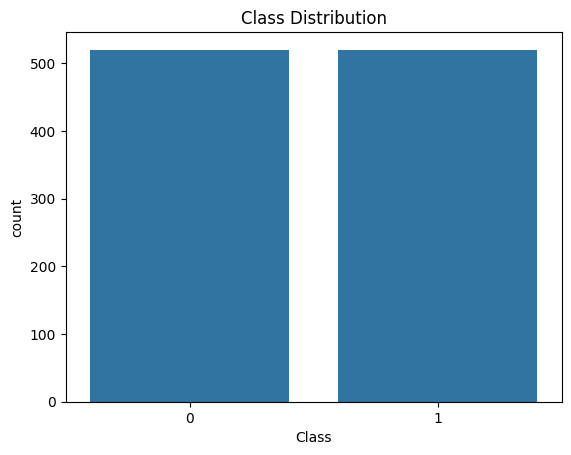

In [124]:
sns.countplot(x="Class", data=train_df)

plt.title("Class Distribution")

plt.show()

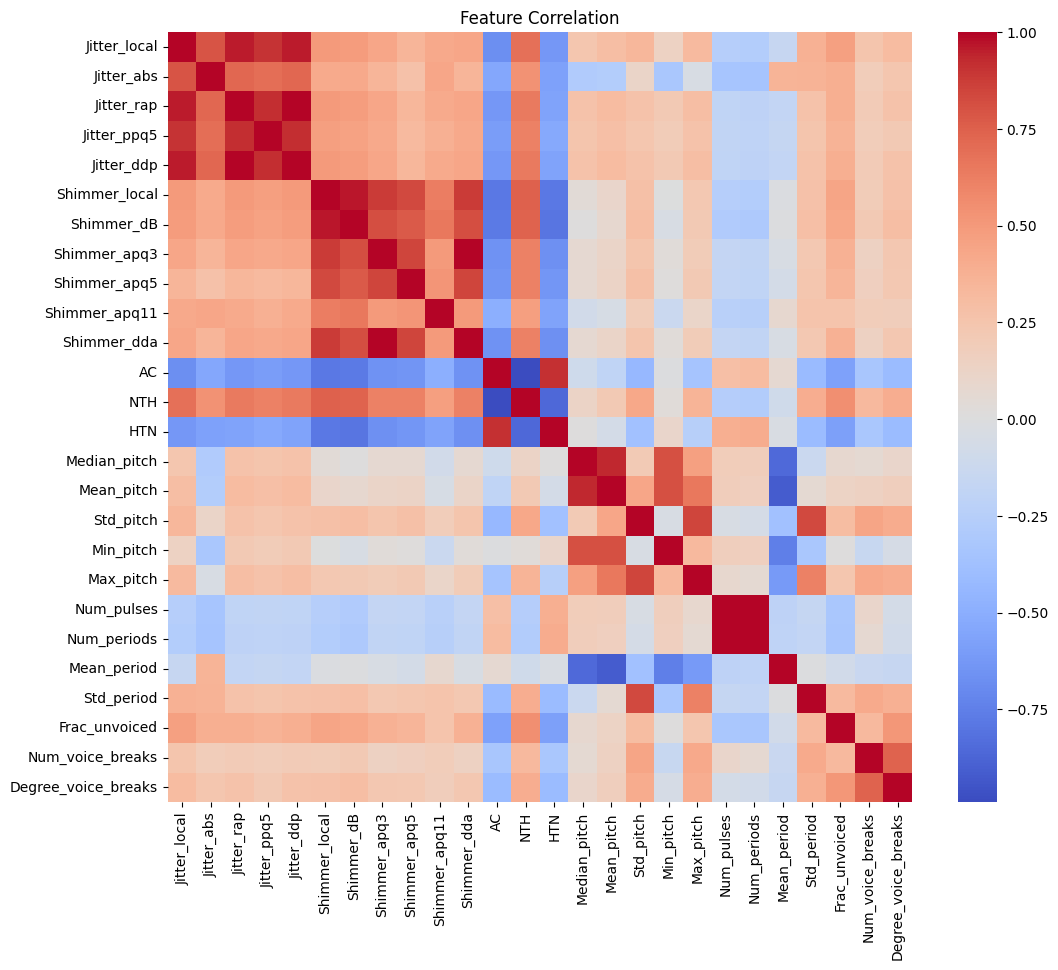

In [125]:
plt.figure(figsize=(12,10))

sns.heatmap(train_df.drop(["Subject_ID","UPDRS","Class"], axis=1).corr(),
            cmap="coolwarm")

plt.title("Feature Correlation")

plt.show()

In [126]:
# Test Dataset

test_columns = [

"Subject_ID",

"Jitter_local","Jitter_abs","Jitter_rap","Jitter_ppq5","Jitter_ddp",

"Shimmer_local","Shimmer_dB","Shimmer_apq3","Shimmer_apq5","Shimmer_apq11","Shimmer_dda",
"AC","NTH","HTN",
"Median_pitch","Mean_pitch","Std_pitch","Min_pitch","Max_pitch",
"Num_pulses","Num_periods","Mean_period","Std_period",
"Frac_unvoiced","Num_voice_breaks","Degree_voice_breaks",
"Class"
]
test_df = pd.read_csv(
"/content/drive/MyDrive/Parkinson's Dataset for Mlops Project/parkinson+speech+dataset+with+multiple+types+of+sound+recordings/test_data.txt",
header=None,
names=test_columns
)

In [127]:
print("Test shape:", test_df.shape)

Test shape: (168, 28)


In [128]:
X = train_df.drop(["Subject_ID","UPDRS","Class"], axis=1)
y = train_df["Class"]

X_test = test_df.drop(["Subject_ID","Class"], axis=1)
y_test = test_df["Class"]

In [129]:
print(X.shape)
print(X_test.shape)

(1040, 26)
(168, 26)


In [130]:
X_train, X_val, y_train, y_val = train_test_split(

    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

In [131]:
scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)

X_val_scaled = scaler.transform(X_val)

X_test_scaled = scaler.transform(X_test)

### Logistic Regression

In [132]:
log_model = LogisticRegression(max_iter=1000)

log_model.fit(X_train_scaled, y_train)

log_pred = log_model.predict(X_val_scaled)

print("Logistic Regression Accuracy:",
      accuracy_score(y_val, log_pred))

print(classification_report(y_val, log_pred))

Logistic Regression Accuracy: 0.6490384615384616
              precision    recall  f1-score   support

           0       0.65      0.65      0.65       104
           1       0.65      0.64      0.65       104

    accuracy                           0.65       208
   macro avg       0.65      0.65      0.65       208
weighted avg       0.65      0.65      0.65       208



### SVM

In [133]:
svm_model = SVC(kernel="rbf", C=10)

svm_model.fit(X_train_scaled, y_train)

svm_pred = svm_model.predict(X_val_scaled)

print("SVM Accuracy:",
      accuracy_score(y_val, svm_pred))

print(classification_report(y_val, svm_pred))

SVM Accuracy: 0.6971153846153846
              precision    recall  f1-score   support

           0       0.69      0.72      0.70       104
           1       0.71      0.67      0.69       104

    accuracy                           0.70       208
   macro avg       0.70      0.70      0.70       208
weighted avg       0.70      0.70      0.70       208



### Random Forest

In [134]:
rf_model = RandomForestClassifier(

    n_estimators=500,
    random_state=42
)

rf_model.fit(X_train, y_train)

rf_pred = rf_model.predict(X_val)

print("Random Forest Accuracy:",
      accuracy_score(y_val, rf_pred))

print(classification_report(y_val, rf_pred))

Random Forest Accuracy: 0.6923076923076923
              precision    recall  f1-score   support

           0       0.69      0.71      0.70       104
           1       0.70      0.67      0.69       104

    accuracy                           0.69       208
   macro avg       0.69      0.69      0.69       208
weighted avg       0.69      0.69      0.69       208



### Gradient Boosting

In [135]:
gb_model = GradientBoostingClassifier(

    n_estimators=300,
    learning_rate=0.05,
    max_depth=3
)

gb_model.fit(X_train, y_train)

gb_pred = gb_model.predict(X_val)

print("Gradient Boosting Accuracy:",
      accuracy_score(y_val, gb_pred))

print(classification_report(y_val, gb_pred))

Gradient Boosting Accuracy: 0.7355769230769231
              precision    recall  f1-score   support

           0       0.74      0.72      0.73       104
           1       0.73      0.75      0.74       104

    accuracy                           0.74       208
   macro avg       0.74      0.74      0.74       208
weighted avg       0.74      0.74      0.74       208



In [136]:
print(len(y_val))
print(len(log_pred))

208
208


In [137]:
results = pd.DataFrame({

"Model":[
"Logistic Regression",
"SVM",
"Random Forest",
"Gradient Boosting"
],

"Validation Accuracy":[
accuracy_score(y_val, log_pred),
accuracy_score(y_val, svm_pred),
accuracy_score(y_val, rf_pred),
accuracy_score(y_val, gb_pred)
]

})

results

,Model,Validation Accuracy
0,Logistic Regression,0.649038
1,SVM,0.697115
2,Random Forest,0.692308
3,Gradient Boosting,0.735577


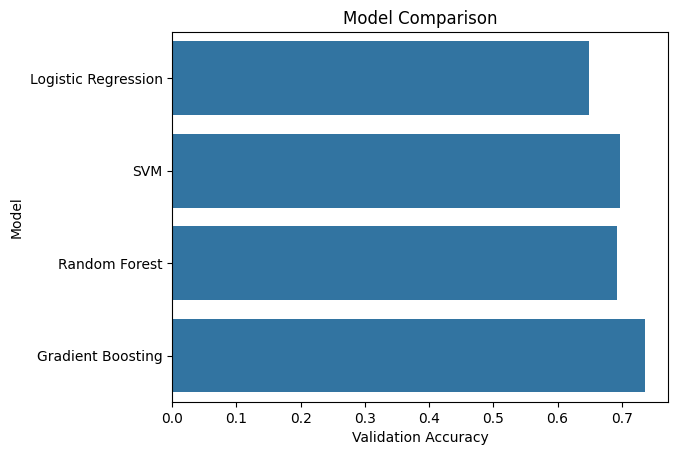

In [138]:
sns.barplot(x="Validation Accuracy", y="Model", data=results)

plt.title("Model Comparison")

plt.show()

In [139]:
best_model = gb_model

### Feature Importance

In [140]:
importances = best_model.feature_importances_

features = X.columns

importance_df = pd.DataFrame({

"Feature":features,
"Importance":importances

}).sort_values("Importance", ascending=False)

importance_df.head(10)

,Feature,Importance
9,Shimmer_apq11,0.107028
14,Median_pitch,0.091492
16,Std_pitch,0.088642
3,Jitter_ppq5,0.061764
23,Frac_unvoiced,0.059514
18,Max_pitch,0.046495
20,Num_periods,0.046088
5,Shimmer_local,0.043077
11,AC,0.042182
17,Min_pitch,0.039428


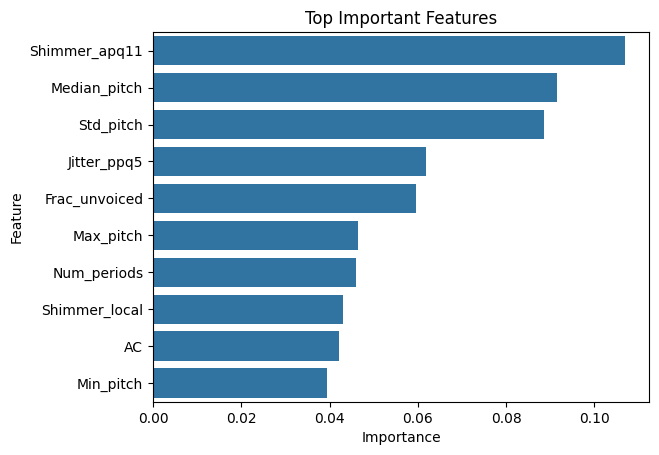

In [141]:
sns.barplot(

x="Importance",
y="Feature",
data=importance_df.head(10)

)

plt.title("Top Important Features")

plt.show()

### Recall

In [142]:
from sklearn.metrics import recall_score
test_pred = best_model.predict(X_test)

recall = recall_score(y_test, test_pred)

print("Parkinson Detection Recall:", recall)

Parkinson Detection Recall: 0.5416666666666666


### Bias-Variance Learning Curve

In [147]:
print(subject_features.shape)
print(subject_labels.shape)

(40, 26)
(40,)


In [148]:
from sklearn.model_selection import learning_curve, StratifiedKFold
from sklearn.ensemble import RandomForestClassifier
import numpy as np
import matplotlib.pyplot as plt

rf_model = RandomForestClassifier(
    n_estimators=150,
    max_depth=3,
    min_samples_split=12,
    min_samples_leaf=6,
    class_weight="balanced",
    random_state=42
)

cv = StratifiedKFold(n_splits=3, shuffle=True, random_state=42)

train_sizes, train_scores, val_scores = learning_curve(
    rf_model,
    subject_features,
    subject_labels,
    cv=cv,
    scoring="accuracy",
    train_sizes=np.linspace(0.3, 1.0, 6)
)

In [149]:
train_mean = np.mean(train_scores, axis=1)
val_mean = np.mean(val_scores, axis=1)

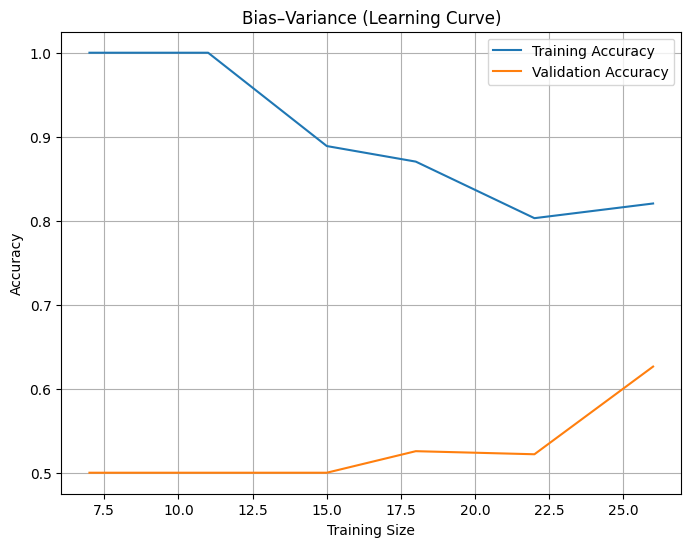

In [150]:
plt.figure(figsize=(8,6))

plt.plot(train_sizes, train_mean, label="Training Accuracy")
plt.plot(train_sizes, val_mean, label="Validation Accuracy")

plt.xlabel("Training Size")
plt.ylabel("Accuracy")
plt.title("Bias–Variance (Learning Curve)")
plt.legend()

plt.grid(True)

plt.show()

### Shap Explainability

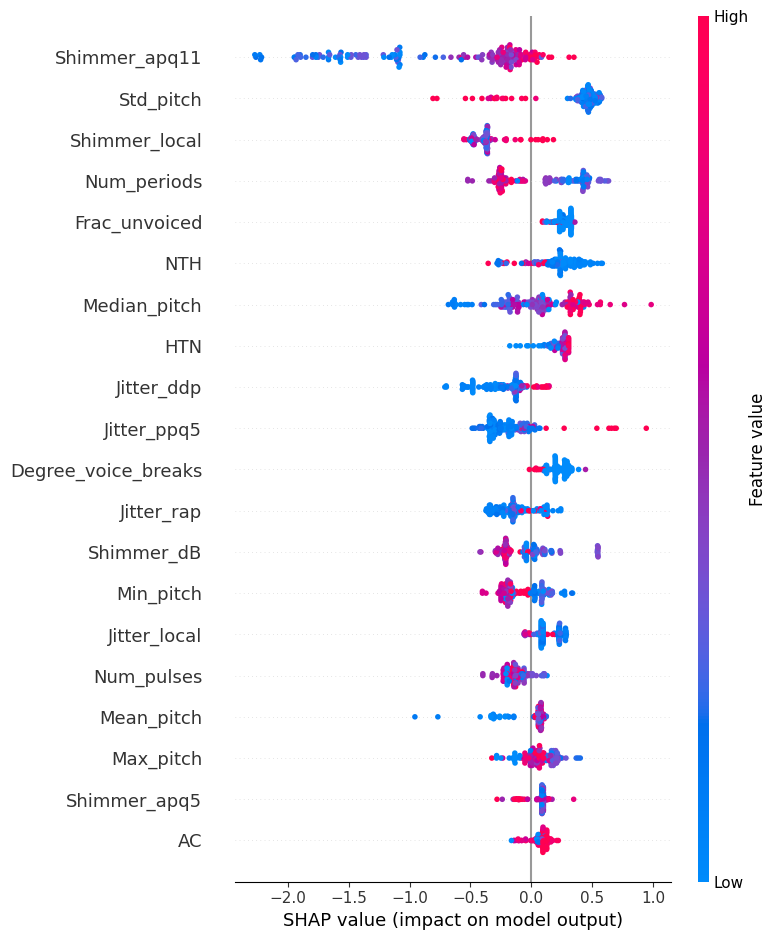

In [151]:
import shap
explainer = shap.TreeExplainer(best_model)

shap_values = explainer.shap_values(X_test)

shap.summary_plot(shap_values, X_test)

### Model Saving


In [152]:
joblib.dump(best_model, "parkinsons_model.pkl")

['parkinsons_model.pkl']